GLOBAL IMPORTS AND CONFIGS

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

import os
import joblib

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve

#GLOBAL VARIABLES

randomState = 128
EPOCHS = 50


ARRAY_PATH = "processed_arrays/"
MODEL_PATH = "models/"
IMAGE_PATH = "images/"

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(IMAGE_PATH, exist_ok=True)
#CHECK CUDA AVAILABILITY

import torch
torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("CUDA Available:", torch.cuda.is_available())

CUDA Available: True


LOADING THE PREPROCESSED DATA

In [2]:
# TRAINING DATA
X_train_prep = np.load(
    ARRAY_PATH + "X_train.npy",
    allow_pickle=True
)

y_train = np.load(
    ARRAY_PATH + "y_train.npy",
    allow_pickle=True
)

# VALIDATION DATA
X_val_prep = np.load(
    ARRAY_PATH + "X_val.npy",
    allow_pickle=True
)

y_val = np.load(
    ARRAY_PATH + "y_val.npy",
    allow_pickle=True
)

# TEST DATA
X_test_prep = np.load(
    ARRAY_PATH + "X_test.npy",
    allow_pickle=True
)

y_test = np.load(
    ARRAY_PATH + "y_test.npy",
    allow_pickle=True
)

feature_names = np.load(
    ARRAY_PATH + "feature_names.npy",
    allow_pickle=True
)

#SHAPE CHECK

print("\nTRAIN SHAPE:")
print(X_train_prep.shape)

print("\nVALIDATION SHAPE:")
print(X_val_prep.shape)

print("\nTEST SHAPE:")
print(X_test_prep.shape)


TRAIN SHAPE:
(700, 19)

VALIDATION SHAPE:
(100, 19)

TEST SHAPE:
(200, 19)


DEFINING THE MODELS

In [3]:
classification_models = {

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=EPOCHS,
        max_depth=10,
        random_state=randomState
    ),

    "XGBoost": XGBClassifier(
        n_estimators=EPOCHS,
        learning_rate=0.05,
        max_depth=6,
        objective="multi:softmax",
        num_class=3,
        tree_method="hist",
        device="cuda",
        eval_metric="merror",
        random_state=randomState
    ),

    "SVM": SVC(
        class_weight="balanced",
        kernel="rbf",
        probability=True,
        random_state=randomState
    )
}

# TRAINING THE MODELS

### RF TRAINING

In [4]:
rf_model = classification_models["Random Forest"]

rf_train_acc = []

rf_val_acc = []

for epoch in range(1, EPOCHS + 1):

    rf_model.set_params(
        n_estimators=epoch
    )

    rf_model.fit(
        X_train_prep,
        y_train
    )

    # TRAIN PREDICTIONS
    train_pred = rf_model.predict(
        X_train_prep
    )

    # VALIDATION PREDICTIONS
    val_pred = rf_model.predict(
        X_val_prep
    )

    # METRICS
    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    rf_train_acc.append(
        train_accuracy
    )

    rf_val_acc.append(
        val_accuracy
    )

print("Random Forest Training Complete")

joblib.dump(rf_model, os.path.join(MODEL_PATH, "random_forest.joblib"))

Random Forest Training Complete


['models/random_forest.joblib']

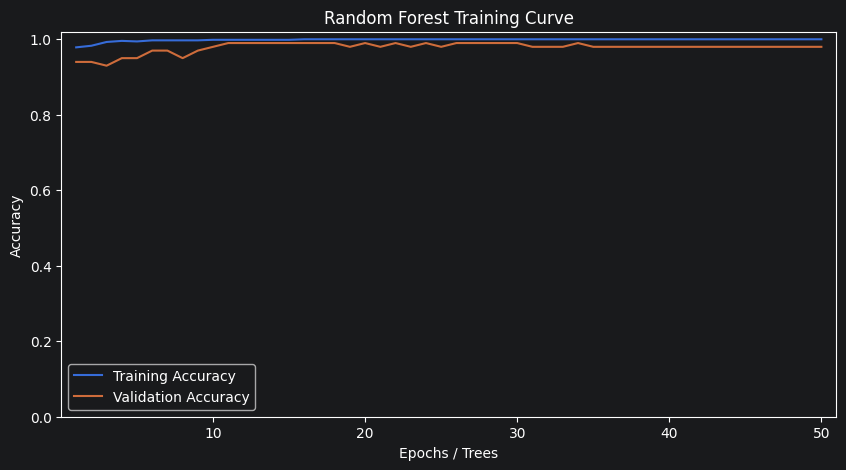

In [5]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=epochs_range,
    y=rf_train_acc,
    label="Training Accuracy"
)

sns.lineplot(
    x=epochs_range,
    y=rf_val_acc,
    label="Validation Accuracy"
)

plt.title("Random Forest Training Curve")

plt.xlabel("Epochs / Trees")

plt.ylabel("Accuracy")

plt.ylim(0, 1.02)

plt.margins(x=0.02)

plt.legend()

plt.savefig(os.path.join(IMAGE_PATH, "rf_training_curve.png"), dpi=300, bbox_inches="tight")

plt.show()

RF FEATURE IMPORTANCE

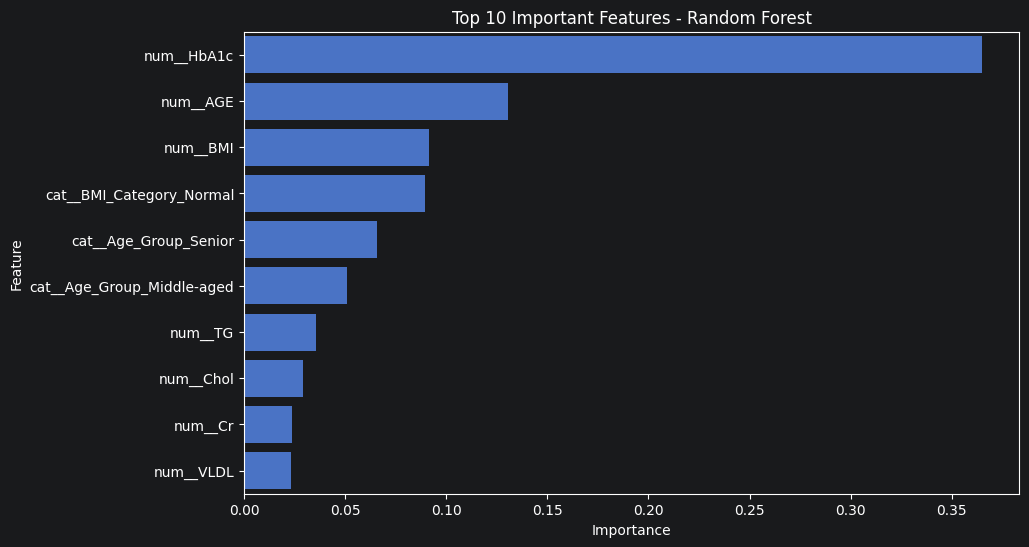

In [6]:
rf_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": rf_model.feature_importances_
})

rf_importance_df = rf_importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")

plt.savefig(os.path.join(IMAGE_PATH, "rf_feature_importance.png"), dpi=300, bbox_inches="tight")

plt.show()

### XGBOOST TRAINING

In [7]:
xgb_model = classification_models["XGBoost"]

xgb_model.fit(

    X_train_prep,
    y_train,

    eval_set=[

        (X_train_prep, y_train),

        (X_val_prep, y_val)
    ],

    verbose=False
)

print("XGBoost Training Complete")

xgb_model.save_model(os.path.join(MODEL_PATH, "xgboost_model.json"))

xgb_results = xgb_model.evals_result()

xgb_train_error = xgb_results[
    "validation_0"
]["merror"]

xgb_val_error = xgb_results[
    "validation_1"
]["merror"]

XGBoost Training Complete


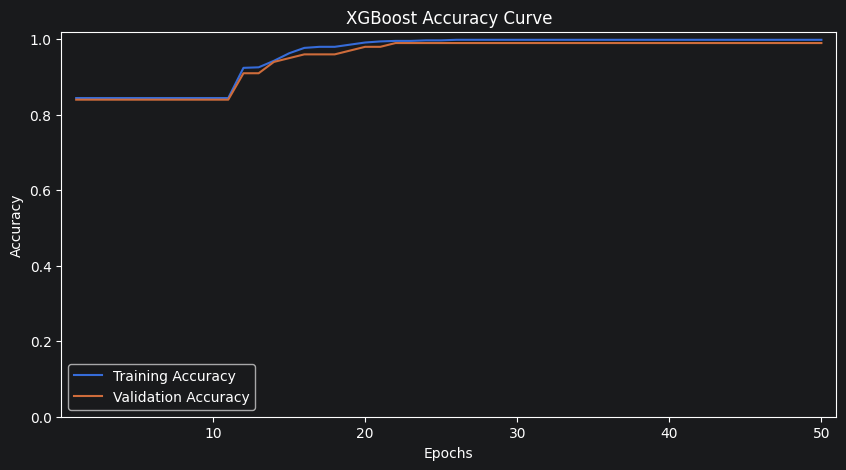

In [8]:
n_epochs = min(len(xgb_train_error), len(xgb_val_error))
epochs_range = range(1, n_epochs + 1)

xgb_train_acc = [1 - err for err in xgb_train_error[:n_epochs]]
xgb_val_acc = [1 - err for err in xgb_val_error[:n_epochs]]

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=epochs_range,
    y=xgb_train_acc,
    label="Training Accuracy"
)

sns.lineplot(
    x=epochs_range,
    y=xgb_val_acc,
    label="Validation Accuracy"
)

plt.title("XGBoost Accuracy Curve")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.ylim(0, 1.02)

plt.margins(x=0.02)

plt.legend()

plt.savefig(os.path.join(IMAGE_PATH, "xgb_accuracy_curve.png"), dpi=300, bbox_inches="tight")

plt.show()

XGBOOST FEATURE IMPORTANCE

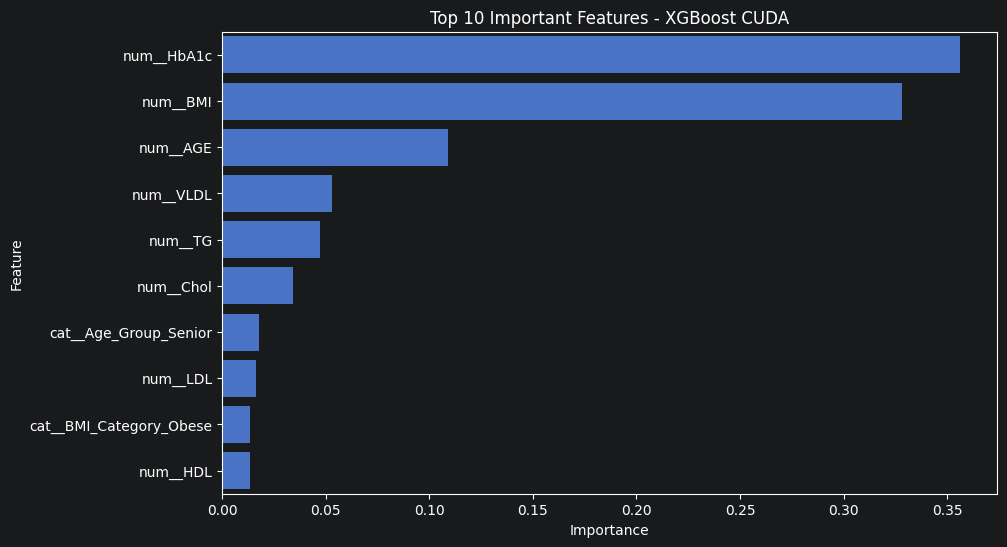

In [9]:
xgb_importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": xgb_model.feature_importances_
})

xgb_importance_df = xgb_importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - XGBoost CUDA")

plt.savefig(os.path.join(IMAGE_PATH, "xgb_feature_importance.png"), dpi=300, bbox_inches="tight")

plt.show()



### SVM TRAINING

In [10]:
svm_model = classification_models["SVM"]

train_sizes, train_scores, val_scores = learning_curve(

    svm_model,

    X_train_prep,
    y_train,

    cv=5,

    train_sizes=np.linspace(
        0.1,
        1.0,
        EPOCHS
    ),

    scoring="accuracy",

    n_jobs=-1
)

svm_train_acc = np.mean(
    train_scores,
    axis=1
)

svm_val_acc = np.mean(
    val_scores,
    axis=1
)

svm_model.fit(X_train_prep, y_train)

joblib.dump(svm_model, os.path.join(MODEL_PATH, "svm_model.joblib"))

print("SVM Training Complete")

SVM Training Complete


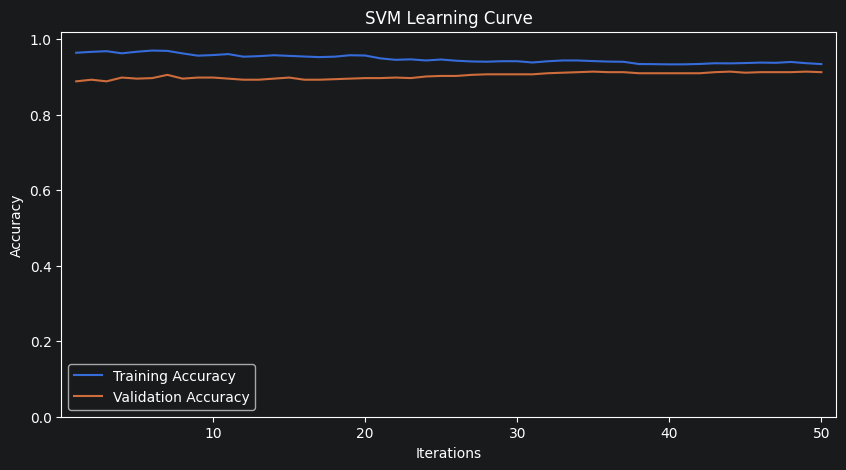

In [11]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=range(1, len(svm_train_acc) + 1),
    y=svm_train_acc,
    label="Training Accuracy"
)

sns.lineplot(
    x=range(1, len(svm_val_acc) + 1),
    y=svm_val_acc,
    label="Validation Accuracy"
)

plt.title("SVM Learning Curve")

plt.xlabel("Iterations")

plt.ylabel("Accuracy")

plt.ylim(0, 1.02)

plt.margins(x=0.02)

plt.legend()

plt.savefig(os.path.join(IMAGE_PATH, "svm_learning_curve.png"), dpi=300, bbox_inches="tight")

plt.show()